# 02: Backward Pass, γ, and ξ — Full Forward-Backward Inference

## Goals
1. Implement the backward pass (β recursion) from Bishop 13.38
2. Compute γ(z_{nk}) = p(z_n = k | X, θ) using α and β (Bishop 13.33)
3. Compute ξ(z_{n-1,j}, z_{nk}) = p(z_{n-1} = j, z_n = k | X, θ) (Bishop 13.43)
4. Verify: γ should infer regimes more sharply than forward-only α, especially at regime transitions
5. Compare forward-only vs forward-backward inference on the same synthetic sequence from notebook 01

## Setup
- Same 2-state Gaussian HMM with hand-set parameters (not learned)
- Same synthetic data generated in notebook 01
- All math follows Bishop PRML 13.2.2

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

In [16]:
pi = np.array([0.8, 0.2]) # (80% chance of starting in calm)
A = np.array([[0.95, 0.05], [0.1, 0.9]]) # (Calm remains 95% of the time, crisis does so 90%)
mu = np.array([0.05, -0.2]) # (Calm has a small positive mean, crisis has negative mean)
sigma_squared = np.array([1.0, 4.0]) # (Crisis has much higher variance)
latent_state = 0 # (0 indexing all states)

In [18]:
N = 500
states, observations = sample_hmm(pi, A, mu, sigma_squared, N)

In [19]:
# Forward pass function for alpha returning array of shape (N, 2)
def forward_pass(observations, pi, A, mu, sigma_squared):
    N = len(observations)
    alpha = np.zeros((N, 2))
    
    # alpha initialization:
    # initial state probability * emission density
    for k in range(2):
        alpha[0,k] = pi[k] * norm.pdf(observations[0], loc=mu[k], scale=np.sqrt(sigma_squared[k]))
    # Need to normalize here since values underflow
    alpha[0, :] /= alpha[0, :].sum()
        
    for n in range(1, N):
        for k in range(2):
            # emission probability of x_n under state k, multiplied by 
            # the sum over all previous states j
            alpha[n,k] = norm.pdf(observations[n], loc=mu[k], scale=np.sqrt(sigma_squared[k]))
            previous_states = 0
            for j in range(2):
                previous_states += alpha[n-1, j] * A[j, k]
            alpha[n, k] *= previous_states
        # Underflow protection
        alpha[n, :] /= alpha[n, :].sum()

    return alpha

In [20]:
# Returning shape (N, 2)
def backward_pass(observations, pi, A, mu, sigma_squared):
    N = len(observations)
    beta = np.zeros((N, 2))

    # Beta initialization
    # beta(z_{Nk})=1
    for k in range(2):
        beta[N - 1, k] = 1

    for n in range(N-2, -1, -1):
        for k in range(2):
            for j in range(2):
                # For each future state j, emission probability of x_{n+1} under state j times transition from k to j times
                # the sum over all future states j
                beta[n, k] += A[k, j] * norm.pdf(observations[n+1], loc=mu[j], scale=np.sqrt(sigma_squared[j])) * beta[n+1, j]

        # Underflow protection
        beta[n, :] /= beta[n, :].sum()

    return beta

In [21]:
alpha = forward_pass(observations, pi, A, mu, sigma_squared)
beta = backward_pass(observations, pi, A, mu, sigma_squared)
# Gamma is alpha[n, k] * beta[n, k] normalized so the two states sum to 1
gamma = alpha * beta
gamma = gamma / gamma.sum(axis=1, keepdims=True)

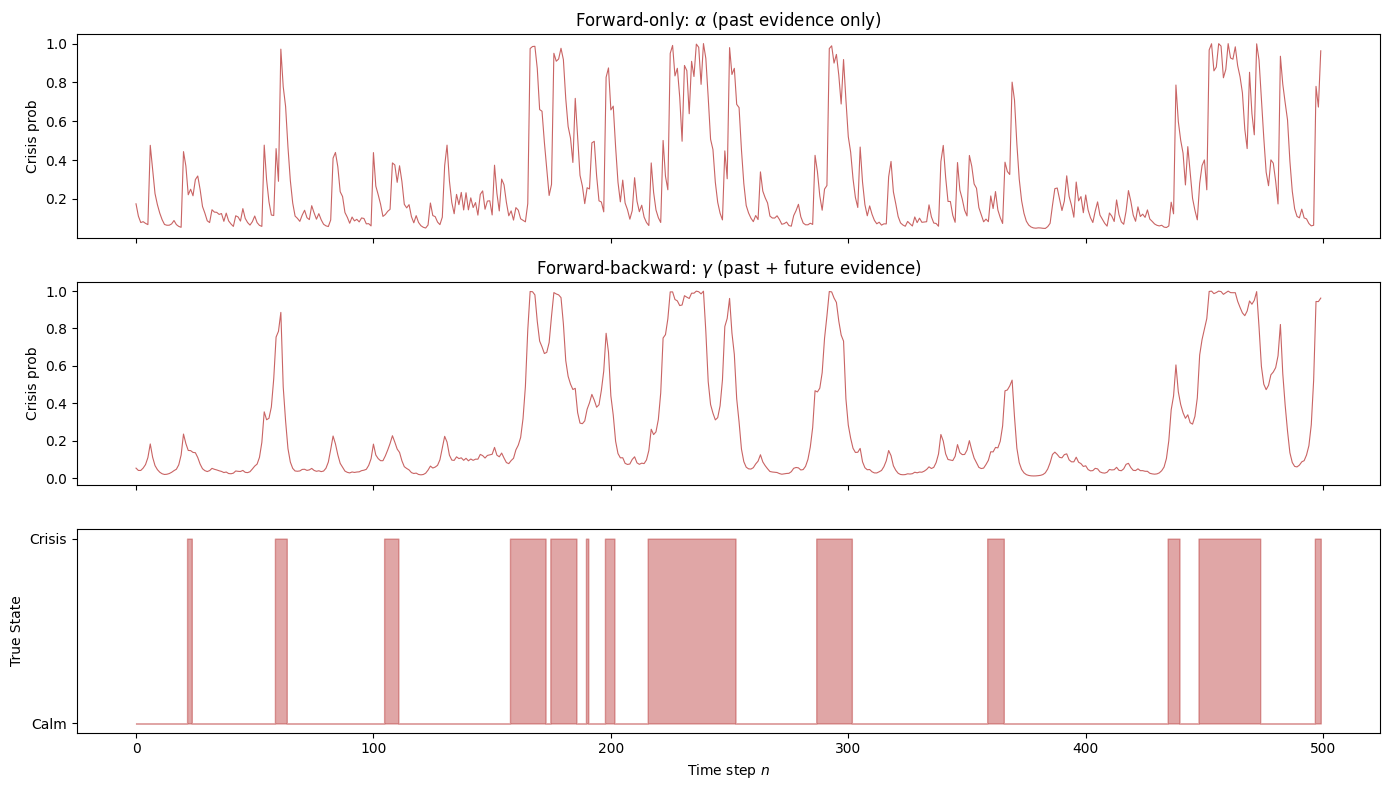

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

ax1.plot(alpha[:, 1], color='firebrick', alpha=0.7, linewidth=0.8)
ax1.set_ylabel('Crisis prob')
ax1.set_title('Forward-only: $\\alpha$ (past evidence only)')

ax2.plot(gamma[:, 1], color='firebrick', alpha=0.7, linewidth=0.8)
ax2.set_ylabel('Crisis prob')
ax2.set_title('Forward-backward: $\\gamma$ (past + future evidence)')

ax3.fill_between(range(N), states, alpha=0.4, color='firebrick', step='mid')
ax3.set_ylabel('True State')
ax3.set_xlabel('Time step $n$')
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Calm', 'Crisis'])

plt.tight_layout()
plt.show()

In [27]:
# At each time step n (from 1 to N - 1), xi[n, j, k] is the posterior probability that 
# the previous state was j and the current state is k. 
# Four components:
# - How much forward evidence supports state j at n - 1 (alpha)
# - How likely the j->k transition is (A)
# - How well x_n matches state k (emisson)
# - How much backward evidence supports state k at n (beta)
xi = np.zeros((N - 1, 2, 2))

for n in range(1, N):
    for j in range(2):
        for k in range(2):
            xi[n - 1, j, k] = (alpha[n-1, j] 
                               * A[j, k]
                               * norm.pdf(observations[n], loc=mu[k], scale=np.sqrt(sigma_squared[k]))
                               * beta[n, k])
    # Normalize so all four entries sum to 1
    xi[n - 1] /= xi[n-1].sum()